# Ejercicio análisis time series
Para este ejercicio vas a trabajar con el histórico de valores en bolsa de una empresa que se dedica a vender muebles. Se pide
1. Importa los datos `df_furniture.csv`
2. Trata la fecha como texto. Crea una columna para el año, mes y dia, y a partir de esas columnas crea la de fecha, en formato datetime de pandas
3. ¿De qué fecha a qué fecha va el histórico?
4. ¿Cómo es la serie temporal? ¿Tiene tendencia? ¿Aprecias alguna estacionalidad?
5. ¿Podrías demostrar de dos maneras estadísticas que la serie no es stationary?
6. Parece que hay una tendencia, pero no se aprecia bien con tanto pico en la serie. ¿Conoces algún método para representar mejor la tendencia?
7. Estaría bien visualizar todos los componentes de la serie temporal por separado
8. Demuestra mediante una gráfica de autocorrelación que la serie es estacional
9. ¿Qué dependencia tiene cada instante de sus últimos 5 lags? Demuéstralo mediante una matriz de correlación. ¿Esto es bueno para los modelos?
10. Ya hemos visto que hay estacionalidad. ¿Cada cuántos instantes se cumple ese patrón?
11. Para un futuro modelado de los datos necesitaremos eliminar la tendencia. ¿Cómo hacemos esto?

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Cargamos los datos

In [78]:
df = pd.read_csv('data/df_furniture.csv', parse_dates = ['Month'], index_col = 'Month')
df

,furniture_price_adjusted
Month,
1992-01-01,2073.432724
1992-02-01,2114.485812
1992-03-01,2260.570891
1992-04-01,2255.103236
1992-05-01,2331.414618
...,...
2019-03-01,9718.107698
2019-04-01,9248.814254
2019-05-01,10001.305304


## 2. Tratar la fecha como texto e interpretar (parse)

In [79]:
#  parse_dates = ['Month']

## 3. ¿De qué fecha a qué fecha va el histórico?

In [80]:
print(f"Primera fecha: {df.index.min()}")
print(f"Última fecha: {df.index.max()}")

Primera fecha: 1992-01-01 00:00:00
Última fecha: 2019-07-01 00:00:00


## 4. ¿Cómo es la serie temporal? ¿Tiene tendencia? ¿Aprecias alguna estacionalidad?

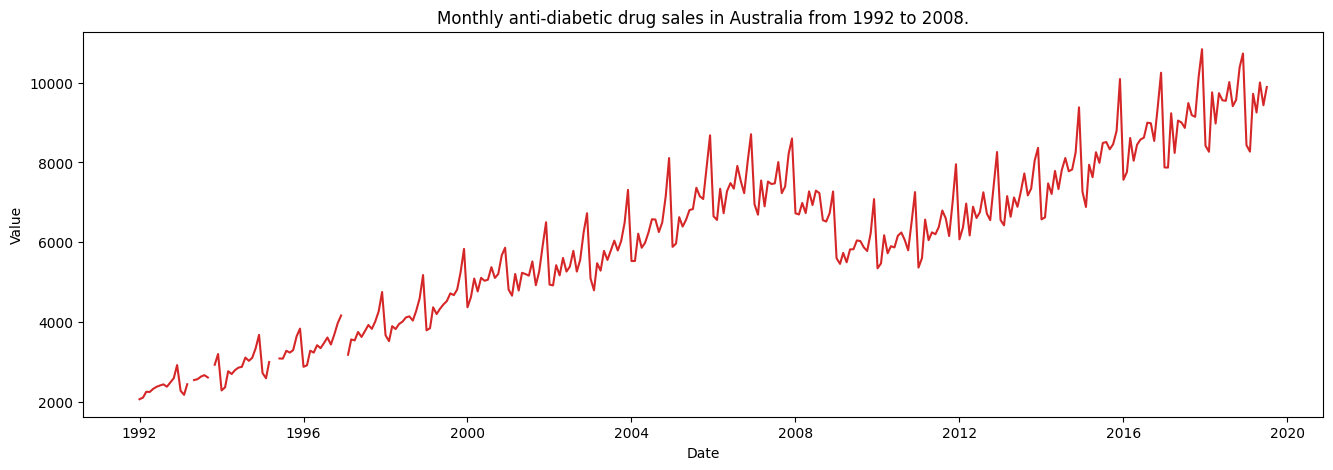

In [81]:
import matplotlib.pyplot as plt

# Draw Plot
def plot_df(df, x, y, title="", xlabel='Date', ylabel='Value', dpi=100):
    plt.figure(figsize=(16,5), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()

plot_df(df, x=df.index, y=df.furniture_price_adjusted, title='Monthly anti-diabetic drug sales in Australia from 1992 to 2008.') 

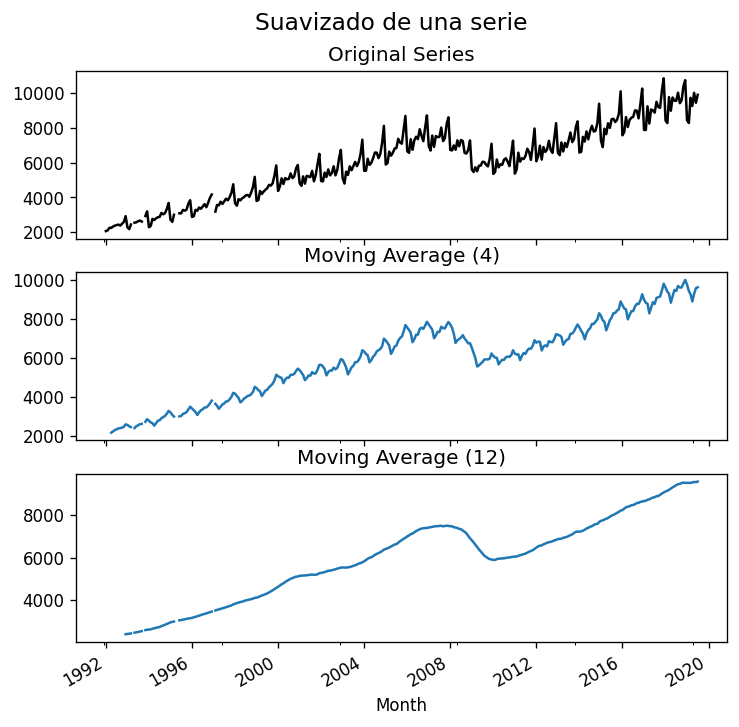

In [82]:
df_ma = df.furniture_price_adjusted.rolling(4).mean()
df_ma_12 = df.furniture_price_adjusted.rolling(12).mean()

# Plot
fig, axes = plt.subplots(3,1, figsize=(7, 7), sharex=True, dpi=120)
df['furniture_price_adjusted'].plot(ax=axes[0], color='k', title='Original Series')
df_ma.plot(ax=axes[1], title='Moving Average (4)')
df_ma_12.plot(ax=axes[2], title='Moving Average (12)')
fig.suptitle('Suavizado de una serie', y=0.95, fontsize=14)
plt.show()

Apreciamos la tendencia aislada al visualizar las madeias móviles con saltos de 12 u (meses)

In [83]:
from statsmodels.tsa.seasonal import seasonal_decompose
result_add = seasonal_decompose(
    df['furniture_price_adjusted'], 
    model='additive', 
    period=12,
    extrapolate_trend='freq'
)

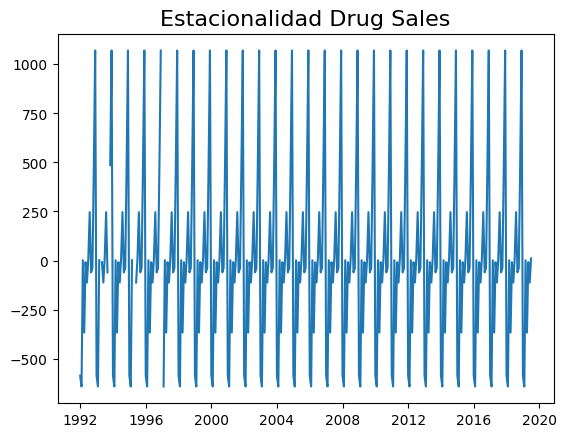

In [84]:
plt.plot(result_add.seasonal)
plt.title('Estacionalidad Drug Sales', fontsize=16);

Vemos la estacionalidad aislaada del resto de factores, vamos a medirla

## 5. ¿Podrías demostrar de dos maneras estadísticas que la serie no es estacionaria?

In [ ]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['furniture_price_adjusted'].values)
result[1]

np.float64(0.7035529748089981)

La serie no es estacionaria según el test de Dickey-Fuller

In [87]:
result_add = seasonal_decompose(
    df['furniture_price_adjusted'], 
    model='additive', 
    period=12,
    extrapolate_trend='freq'
)

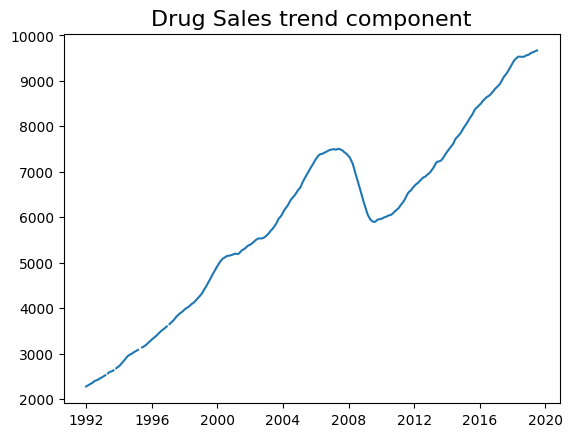

In [88]:
plt.plot(result_add.trend)
plt.title('Drug Sales trend component', fontsize=16);

Sin la tendencia, vemos que el valor cambia con el tiempo, aquí tambien apreciamos la no-estacionariedad de los datos

## 6. ¿Conoces algún método para representar mejor la tendencia?

In [89]:
# Code

## 7. Estaría bien visualizar todos los componentes de la serie temporal por separado

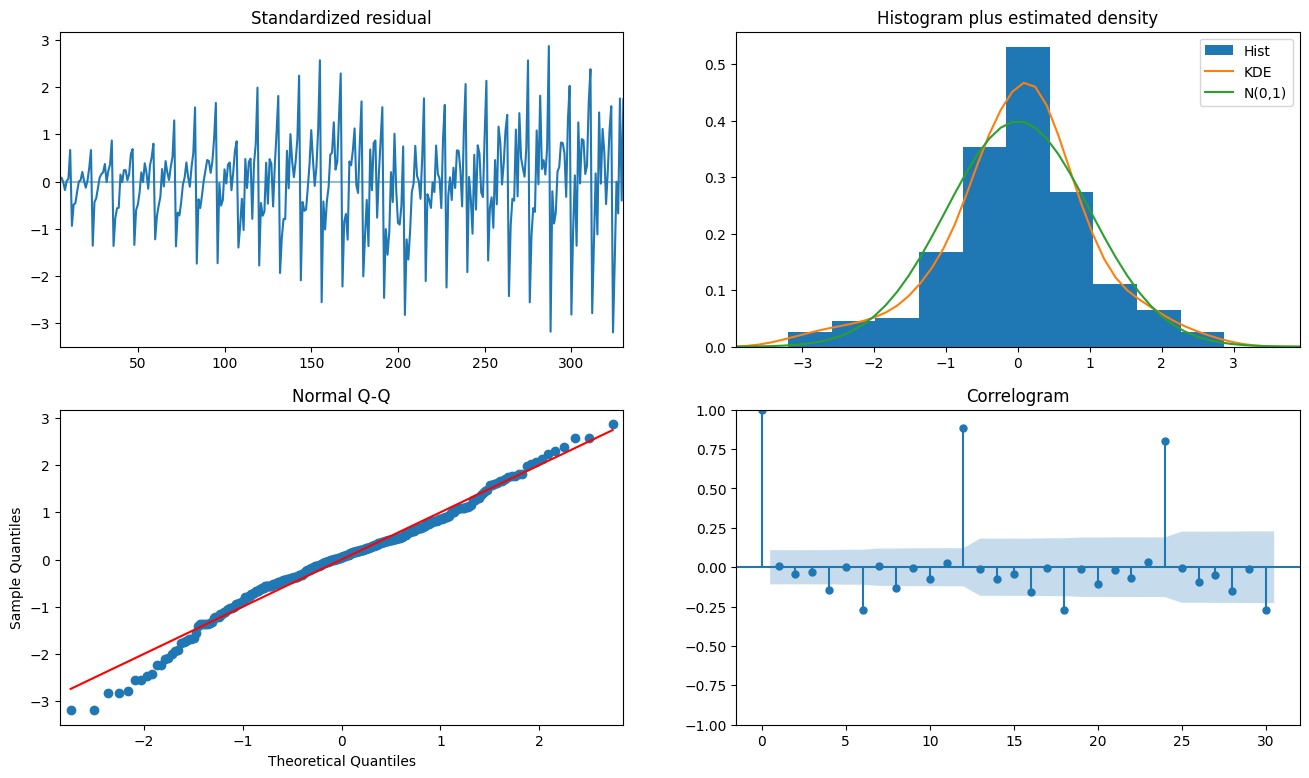

In [90]:
fig = plt.figure(figsize=(16, 9))
fig = res.plot_diagnostics(fig=fig, lags=30)

## 8. Demuestra mediante una gráfica de autocorrelación que la serie es estacional

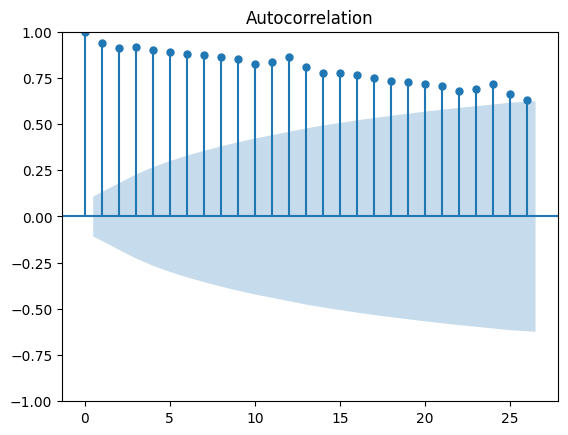

In [91]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df);

## 9. ¿Qué dependencia tiene cada instante de sus últimos 5 lags? Demuéstralo mediante una matriz de correlación.

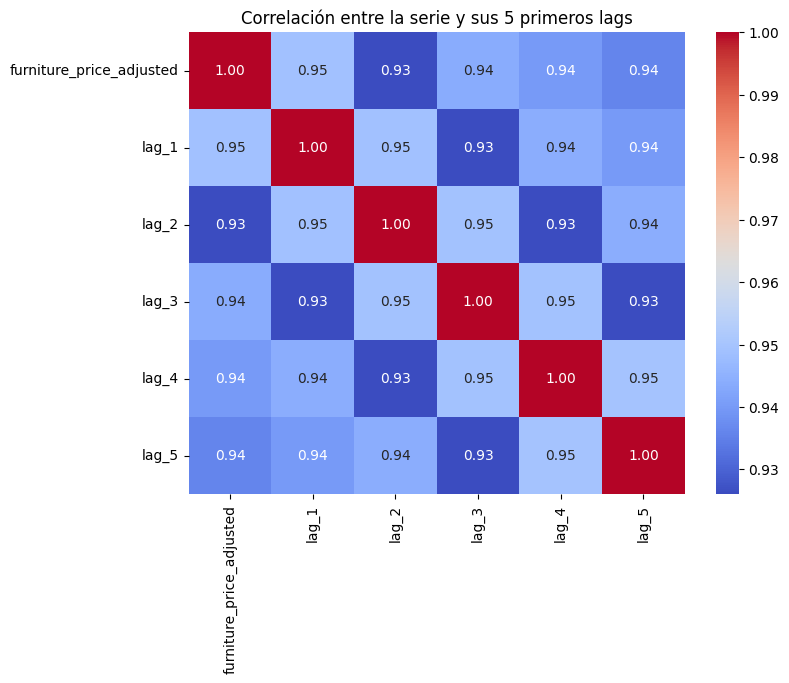

In [92]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

for i in range(1, 6):
    df[f'lag_{i}'] = df['furniture_price_adjusted'].shift(i)

# Eliminar las filas con NaN (las primeras 5 filas)
df_lags_clean = df.dropna()

corr_matrix = df_lags_clean.corr()

# Visualización opcional
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación entre la serie y sus 5 primeros lags')
plt.show()

## 10. Ya hemos visto que hay estacionalidad. ¿Cada cuántos instantes se cumple ese patrón?

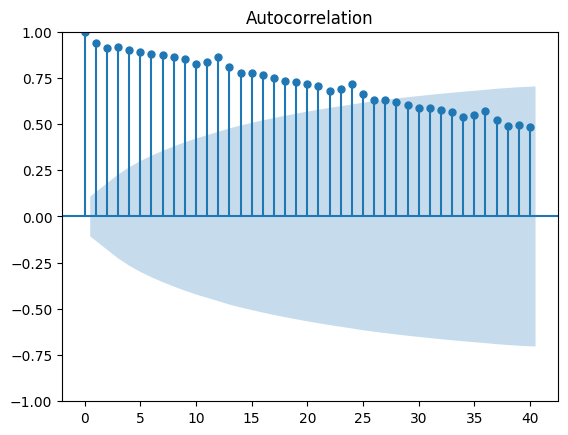

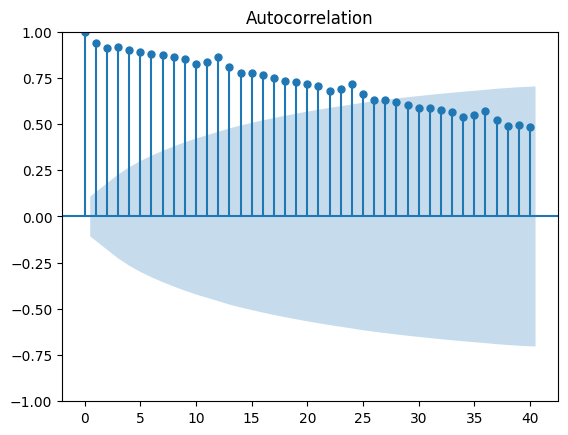

In [98]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['furniture_price_adjusted'], lags=40)

Vemos un repunte cada 12 meses y un patron

## 11. Para un futuro modelado de los datos necesitaremos eliminar la tendencia. ¿Cómo hacemos esto?

con un seasonal_decompose

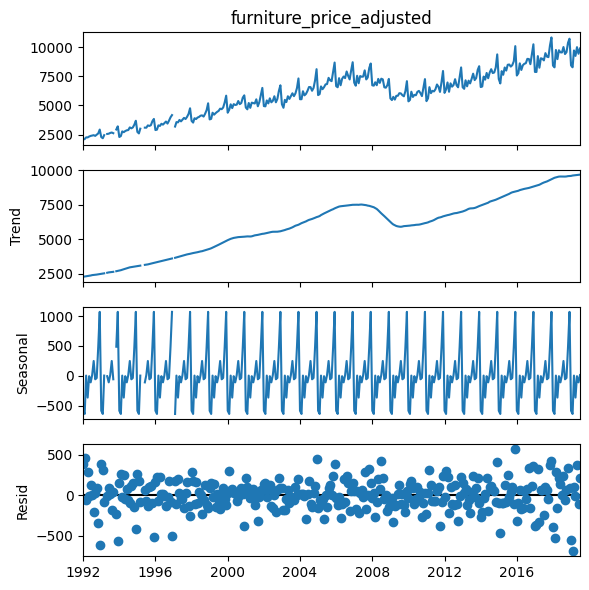

In [99]:
result_add = seasonal_decompose(
    df['furniture_price_adjusted'], 
    model='additive', 
    period=12,
    extrapolate_trend='freq'
)

plt.rcParams.update({'figure.figsize': (6,6)})
result_add.plot();